# Cut — patching a Sentinel-2 scene over Lake Tahoe

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geotoolz/blob/main/docs/patcher/notebooks/patcher_lake_tahoe.ipynb)

You split a 10 km box of a Sentinel-2 scene into overlapping patches, run an operator on each one, and stitch the results back. This is step 2 of the Lake Tahoe story. The [find notebook](https://jejjohnson.github.io/geotoolz/catalog/notebooks/end_to_end_lake_tahoe/) chose the scene, 2024-09-22; the [compute notebook](https://jejjohnson.github.io/geotoolz/operators/notebooks/operators_lake_tahoe/) covers the operators.

The four patcher axes (geometry, sampler, window, aggregation) are explained once in [Patcher concepts](https://jejjohnson.github.io/geotoolz/patcher/concepts/). Here you see them on real pixels.

**What you'll learn:**

1. Read a decimated overview of a whole tile, without downloading it.
2. Load a 10 km box at native 10 m resolution through the catalog.
3. Inspect a `SpatialPatcher`'s anchors and the `Patch` objects it yields.
4. See why the window axis matters for operators that look at a whole chip.
5. Run split → apply → stitch as one operator with `geotoolz.patch_ops`.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo: str = "git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages"
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pipekit @ git+https://github.com/jejjohnson/pipekit#subdirectory=packages/pipekit",
            f"geotoolz-patcher @ {repo}/geotoolz-patcher",
            f"geotoolz @ {repo}/geotoolz",
            f"geotoolz-catalog[stac] @ {repo}/geotoolz-catalog",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
from georeader.geotensor import GeoTensor
from georeader.rasterio_reader import RasterioReader

import geocatalog as gc
import geopatcher as gp
import geotoolz as gz
from geotoolz.patch_ops import ApplyToChips, GridSampler, MergePatches

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,matplotlib,geocatalog,geopatcher,geotoolz",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.16
IPython version      : 9.13.0

numpy     : 2.4.5
matplotlib: 3.10.9
geocatalog: 0.4.0
geopatcher: 0.10.0
geotoolz  : 0.9.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v80
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. Find the scene

Search the one date the find notebook chose, and keep red and NIR from the UTM zone 10 tile. That tile covers the whole AOI, so its native grid needs no reprojection.

In [4]:
client: pystac_client.Client = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
catalog: gc.GeoCatalog = gc.sources.from_stac_search(
    client,
    collections=["sentinel-2-l2a"],
    bounds=(-120.25, 38.85, -119.85, 39.30),  # Lake Tahoe, lon/lat
    datetime="2024-09-22",
    asset_key="*",
).where("asset_key in ['B04', 'B08'] and crs == 'EPSG:32610'")
catalog.gdf[["asset_key", "stac_item_id", "crs"]]

,asset_key,stac_item_id,crs
datetime,,,
"[2024-09-22 18:40:09.024000, 2024-09-22 18:40:09.024000]",B04,S2B_MSIL2A_20240922T184009_R070_T10SGJ_2024092...,EPSG:32610
"[2024-09-22 18:40:09.024000, 2024-09-22 18:40:09.024000]",B08,S2B_MSIL2A_20240922T184009_R070_T10SGJ_2024092...,EPSG:32610


## 2. Preview the tile from an overview

A Cloud-Optimized GeoTIFF stores downsampled copies of itself. `overview_level=2` reads the 1/8 copy, about 80 m per pixel, so the whole 110 km tile costs a few megabytes. The orange square is the South Shore box you patch below.

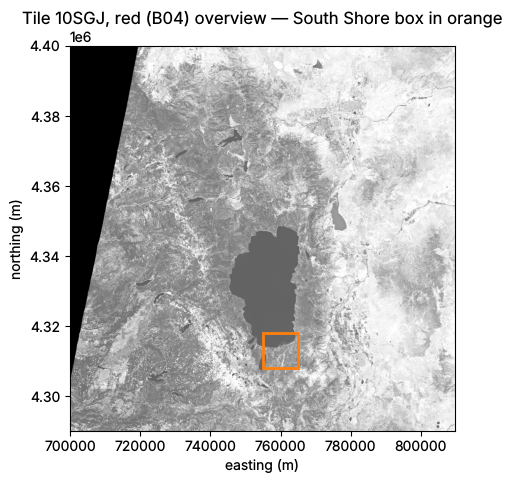

In [5]:
red_href: str = catalog.where("asset_key == 'B04'").gdf["filepath"].iloc[0]
reader: RasterioReader = RasterioReader(red_href, overview_level=2)  # lazy
overview: GeoTensor = reader.load()  # (1, 1373, 1373) uint16, ≈ 80 m pixels
BOX: tuple[float, float, float, float] = (755e3, 4308e3, 765e3, 4318e3)  # UTM 10N, m

ov_bounds: tuple[float, float, float, float] = overview.bounds
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(
    np.asarray(overview)[0],
    cmap="Greys_r",
    vmin=0,
    vmax=3000,
    extent=(ov_bounds[0], ov_bounds[2], ov_bounds[1], ov_bounds[3]),
)
ax.add_patch(
    mpatches.Rectangle(
        (BOX[0], BOX[1]),
        BOX[2] - BOX[0],
        BOX[3] - BOX[1],
        fill=False,
        edgecolor="C1",
        lw=2,
    )
)
ax.set_title("Tile 10SGJ, red (B04) overview — South Shore box in orange")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
plt.show()

## 3. Load the box as a field

`gc.load.load_raster` reads only the box's pixels from each remote file. Stack red and NIR, then wrap the result as a `gp.RasterField`, the object a patcher splits.

In [6]:
day: pd.Timestamp = pd.Timestamp("2024-09-22")
south_shore: gc.GeoSlice = gc.GeoSlice(
    bounds=BOX,
    interval=pd.Interval(day, day + pd.Timedelta(hours=23, minutes=59), closed="both"),
    resolution=(10.0, 10.0),  # native Sentinel-2 grid
    crs="EPSG:32610",
)
red_rows: gc.GeoCatalog = catalog.where("asset_key == 'B04'")
nir_rows: gc.GeoCatalog = catalog.where("asset_key == 'B08'")
red: GeoTensor = gc.load.load_raster(red_rows, south_shore)  # (1, 1000, 1000) uint16
nir: GeoTensor = gc.load.load_raster(nir_rows, south_shore)  # (1, 1000, 1000) uint16
scene: GeoTensor = gz.StackBands()([red, nir])  # (2, 1000, 1000) uint16
field: gp.RasterField = gp.RasterField(scene)
print(f"scene: {scene.shape} {scene.dtype}, crs={scene.crs}")

scene: (2, 1000, 1000) uint16, crs=EPSG:32610


## 4. Build the patcher and look at its anchors

256 × 256 chips every 192 px give a 64 px overlap. `boundary="pad"` lets the last row and column of chips run past the edge, so every pixel is covered (see [Boundary policies](https://jejjohnson.github.io/geotoolz/patcher/concepts/#boundary-policies)).

25 anchors, first three: [(0, 0), (0, 192), (0, 384)]


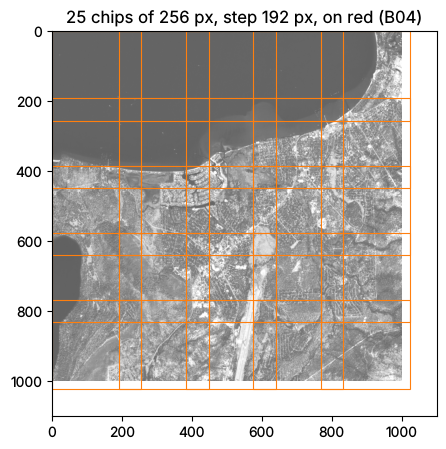

In [7]:
SIZE: int = 256
STEP: int = 192


def make_patcher(taper: gp.spatial.window.Window) -> gp.SpatialPatcher:
    """A 256² / 192-step patcher with the given window."""
    return gp.SpatialPatcher(
        geometry=gp.spatial.geometry.Rectangular(size=(SIZE, SIZE), boundary="pad"),
        sampler=gp.spatial.sampler.RegularStride(step=(STEP, STEP)),
        window=taper,
        aggregation=gp.spatial.aggregation.OverlapAdd(),
    )


patcher: gp.SpatialPatcher = make_patcher(gp.spatial.window.Hann())
anchors: list[tuple[int, int]] = patcher.anchors(field)
print(f"{len(anchors)} anchors, first three: {anchors[:3]}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(np.asarray(scene)[0], cmap="Greys_r", vmin=0, vmax=3000)
for row, col in anchors:
    ax.add_patch(
        mpatches.Rectangle((col, row), SIZE, SIZE, fill=False, edgecolor="C1", lw=0.8)
    )
ax.set_xlim(-0.5, 1100)
ax.set_ylim(1100, -0.5)
ax.set_title(f"{len(anchors)} chips of {SIZE} px, step {STEP} px, on red (B04)")
plt.show()

## 5. Inspect one patch

`split` yields `Patch` objects lazily. Each carries its chip (`data`), where it sits in the field (`anchor`, `indices`) and its window weights.

In [8]:
first: gp.Patch = next(iter(patcher.split(field)))
chip: np.ndarray = np.asarray(first.data)  # (2, 256, 256) uint16
weights: np.ndarray = np.asarray(first.weights)  # (256, 256) float64
print(f"data:    {type(first.data).__name__} {chip.shape} {chip.dtype}")
print(f"anchor:  {first.anchor}")
print(f"indices: {first.indices}")
print(
    f"weights: {weights.shape}, {weights.min():.2f} at the edge, {weights.max():.2f} inside"
)

data:    GeoTensor (2, 256, 256) uint16
anchor:  (0, 0)
indices: Window(col_off=0, row_off=0, width=256, height=256)
weights: (256, 256), 0.00 at the edge, 1.00 inside


## 6. Why the window matters

A per-pixel operator such as NDVI stitches exactly with any window; the find notebook checked that. An operator that reads the whole chip does not. `gz.PercentileClip` stretches each chip by its own 2nd–98th percentiles, so neighbouring chips disagree where they overlap.

With `Boxcar` (flat weights) those disagreements show as hard seams. `Hann` tapers each chip to zero at its edge, so overlap-add blends one chip into the next. See [Window convention](https://jejjohnson.github.io/geotoolz/patcher/patching/#window-convention) for the details.

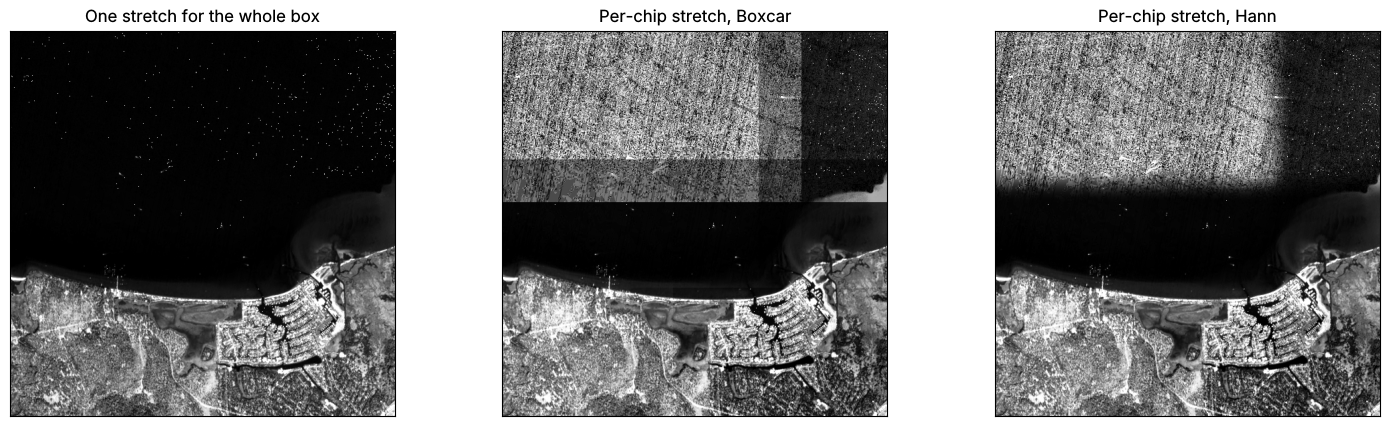

In [9]:
stretch: gz.PercentileClip = gz.PercentileClip(lower=2.0, upper=98.0)
stitched: dict[str, GeoTensor] = {}
tapers: dict[str, gp.spatial.window.Window] = {
    "Boxcar": gp.spatial.window.Boxcar(),
    "Hann": gp.spatial.window.Hann(),
}
for name, taper in tapers.items():
    p: gp.SpatialPatcher = make_patcher(taper)
    chips: list[gp.Patch] = [c.with_data(stretch(c.data)) for c in p.split(field)]
    stitched[name] = p.merge(chips, field.domain)  # → (2, 1000, 1000) float64
whole: GeoTensor = stretch(scene)  # (2, 1000, 1000) uint16 → (2, 1000, 1000) float64

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panels: dict[str, GeoTensor] = {
    "One stretch for the whole box": whole,
    "Per-chip stretch, Boxcar": stitched["Boxcar"],
    "Per-chip stretch, Hann": stitched["Hann"],
}
for ax, (title, img) in zip(axes, panels.items(), strict=True):
    ax.imshow(np.asarray(img)[0, :576, :576], cmap="Greys_r", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

The panels zoom on the top-left 3 × 3 chips, where lake meets shore. Boxcar shows hard edges where one chip's stretch hands over to the next. Hann turns those edges into smooth gradients, though the lake's shading still varies because each chip stretched it differently.

## 7. The same loop as one operator

`geotoolz.patch_ops` wraps split, apply and stitch as three pipekit operators. Chained in a `Sequential`, they become one operator you can compose, serialise and drop into a larger pipeline.

In [10]:
tiled: gz.Sequential = gz.Sequential(
    [
        GridSampler(patcher=patcher),  # field → list[Patch]
        ApplyToChips(operator=stretch),  # (2, 256, 256) uint16 → float64 per chip
        MergePatches(aggregation=patcher.aggregation, domain=field.domain),
    ]
)
result: GeoTensor = tiled(field)  # (2, 1000, 1000) uint16 → (2, 1000, 1000) float64
hann: GeoTensor = stitched["Hann"]  # (2, 1000, 1000) float64
same: bool = np.allclose(np.asarray(result), np.asarray(hann), equal_nan=True)
print(f"result: {result.shape} {result.dtype}; matches the manual Hann loop: {same}")

result: (2, 1000, 1000) float64; matches the manual Hann loop: True


## Summary

- An overview read previews a whole tile for a few megabytes.
- `load_raster` read a native-resolution window; `RasterField` made it splittable.
- `split` yields `Patch` objects with data, position and window weights; `merge` stitches them.
- Operators that read a whole chip need a tapered window such as `Hann` to hide seams.
- `GridSampler → ApplyToChips → MergePatches` turns the loop into one operator.

**Next:** [compute](https://jejjohnson.github.io/geotoolz/operators/notebooks/operators_lake_tahoe/) a cloud-masked NDVI on this window. For outputs too big for memory, see [Streaming overlap-add](https://jejjohnson.github.io/geotoolz/patcher/recipes/streaming-overlap-add/).